# ❤️ Task 3: Heart Disease Prediction

## Problem Statement
Cardiovascular disease is the **leading cause of death globally**. Early prediction of heart disease risk using patient health data can enable timely medical intervention. In this task, we build a **binary classification model** to predict whether a patient is at risk of heart disease.

## Goal
- Load and clean the Heart Disease UCI dataset
- Perform thorough EDA to discover risk patterns
- Train **Logistic Regression** and **Decision Tree** classifiers
- Evaluate using Accuracy, ROC-AUC, and Confusion Matrix
- Identify the most important features driving prediction

## Target Variable
> `target = 1` → Patient **has** heart disease &nbsp;|&nbsp; `target = 0` → Patient **does not** have heart disease

---

## Step 1: Install & Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold

# Scikit-learn — models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

# Scikit-learn — evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

# Plot style
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2: Load the Dataset

> The Heart Disease UCI dataset is loaded directly from the **UCI ML Repository** via URL — no Kaggle download needed in Colab.

In [5]:
# ── Mount Google Drive ────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Load heart.csv from your Drive/datasets folder ───────────────
import pandas as pd

FILE_PATH = '/content/drive/MyDrive/datasets/heart.csv'

df = pd.read_csv(FILE_PATH)


print('✅ Dataset loaded from Google Drive!')
print(f'📐 Shape: {df.shape}')
print(f'📌 Columns: {df.columns.tolist()}')
print(f'🎯 Target values: {sorted(df["target"].unique())}')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded from Google Drive!
📐 Shape: (1025, 14)
📌 Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
🎯 Target values: [np.int64(0), np.int64(1)]


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


---
## Step 3: Data Cleaning

In [6]:
# --- Missing Values ---
print('❓ Missing values per column:')
missing = df.isnull().sum()
print(missing[missing > 0])
print(f'\nTotal missing: {missing.sum()} out of {df.size} cells ({missing.sum()/df.size*100:.2f}%)')

❓ Missing values per column:
Series([], dtype: int64)

Total missing: 0 out of 14350 cells (0.00%)


In [7]:
# Strategy: Impute missing values with MEDIAN (robust to outliers for medical data)
for col in df.columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  ✔ {col}: filled {missing[col]} NaN(s) with median = {median_val}')

print(f'\n✅ No missing values remaining: {df.isnull().sum().sum()}')


✅ No missing values remaining: 0


In [8]:
# --- Data Types ---
print('📋 Data types after cleaning:')
print(df.dtypes)

# Ensure categorical columns are integer type
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cat_cols:
    df[col] = df[col].astype(int)

print('\n✅ Data types corrected.')

📋 Data types after cleaning:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

✅ Data types corrected.


In [9]:
# --- Class Balance ---
counts = df['target'].value_counts()
print('🎯 Target Class Distribution:')
print(f'  No Disease (0): {counts[0]} patients ({counts[0]/len(df)*100:.1f}%)')
print(f'  Disease    (1): {counts[1]} patients ({counts[1]/len(df)*100:.1f}%)')
print(f'\n→ Dataset is reasonably balanced — no oversampling needed.')

🎯 Target Class Distribution:
  No Disease (0): 499 patients (48.7%)
  Disease    (1): 526 patients (51.3%)

→ Dataset is reasonably balanced — no oversampling needed.


---
## Step 4: Exploratory Data Analysis (EDA)

In [10]:
# --- Summary Statistics ---
print('📊 Descriptive Statistics:')
df.describe().round(2)

📊 Descriptive Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


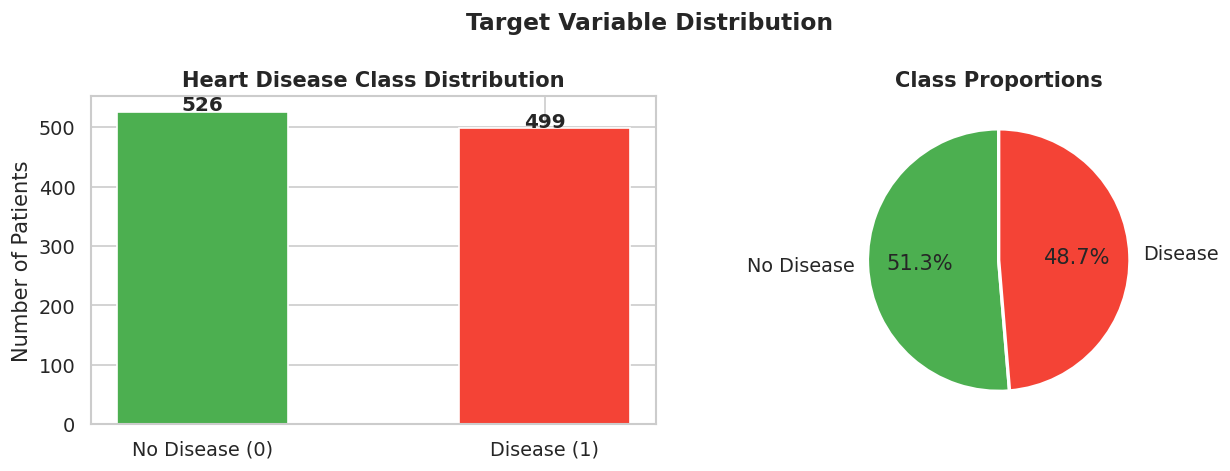

In [11]:
# ── EDA Plot 1: Target Distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count plot
colors = ['#4CAF50', '#F44336']
axes[0].bar(['No Disease (0)', 'Disease (1)'], counts.values, color=colors,
            edgecolor='white', width=0.5)
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1.5, str(val),
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Heart Disease Class Distribution')
axes[0].set_ylabel('Number of Patients')

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Disease'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportions')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

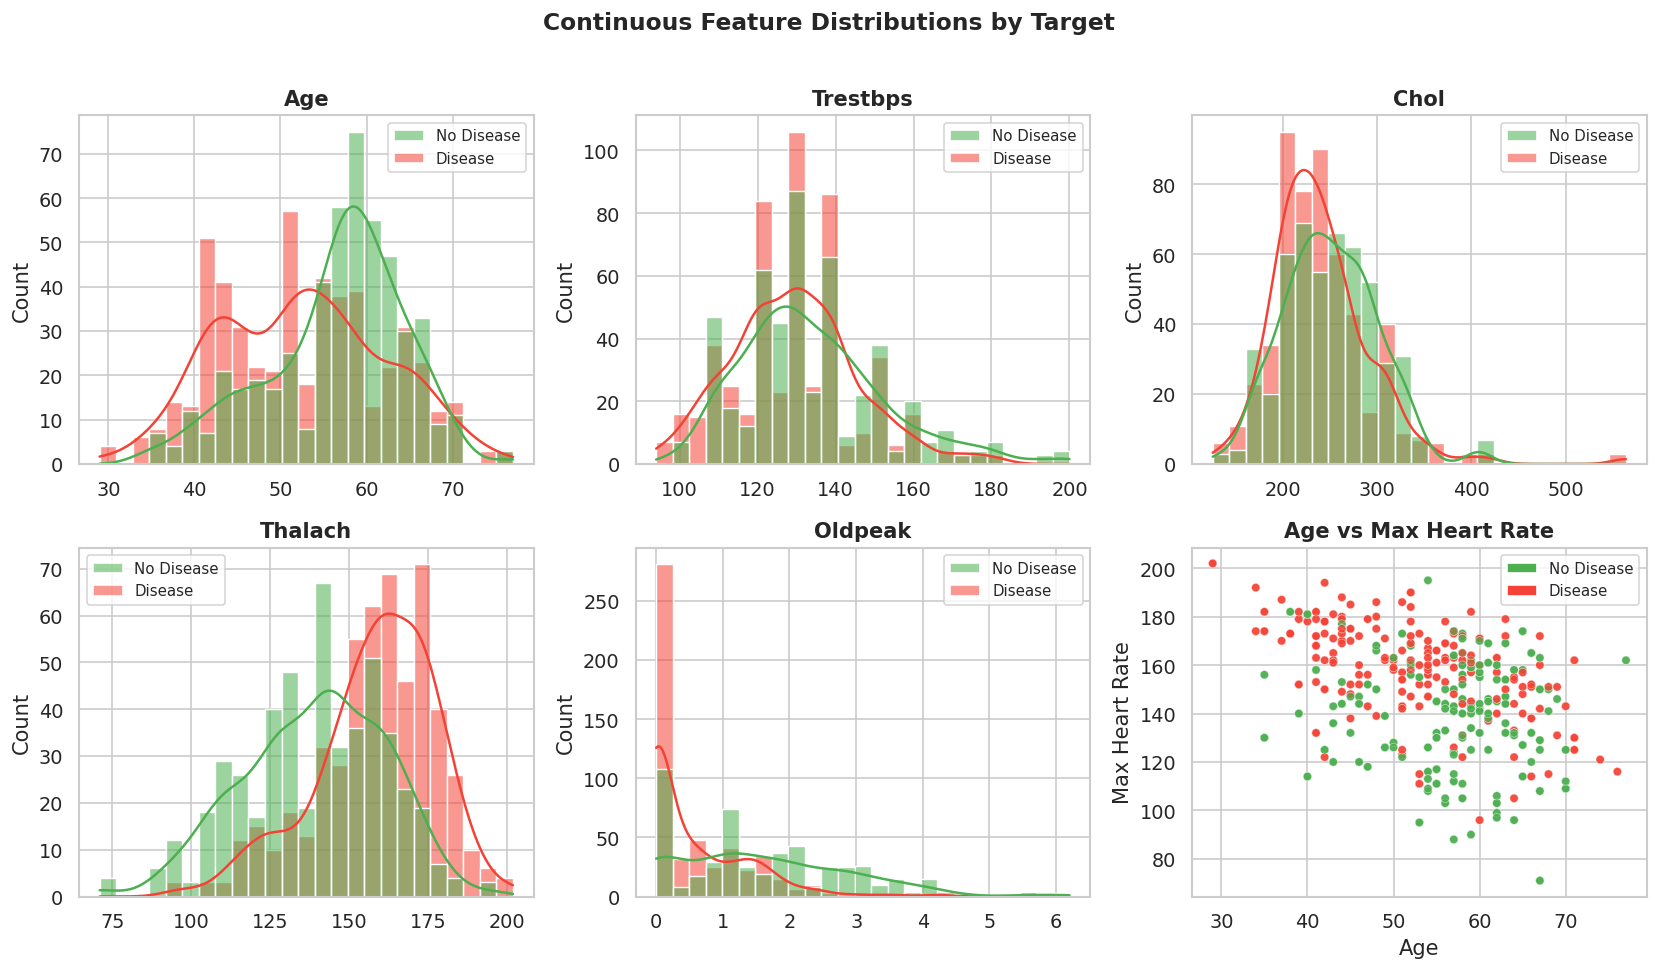

💡 Insights:
  • Higher thalach (max heart rate) → lower disease risk
  • Higher oldpeak (ST depression) → higher disease risk
  • Younger patients more likely to have disease in this dataset


In [12]:
# ── EDA Plot 2: Continuous Features by Target ────────────────────────
cont_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
labels = {0: 'No Disease', 1: 'Disease'}
palette = {0: '#4CAF50', 1: '#F44336'}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(cont_features):
    sns.histplot(
        data=df, x=feat, hue='target',
        kde=True, palette=palette,
        bins=25, alpha=0.55, ax=axes[i]
    )
    axes[i].set_title(feat.replace('_', ' ').title())
    axes[i].set_xlabel('')
    # Custom legend
    handles = axes[i].get_legend().legend_handles
    axes[i].legend(handles, ['No Disease', 'Disease'], fontsize=9)

# Age vs Max Heart Rate scatter
sc = axes[5].scatter(
    df['age'], df['thalach'],
    c=df['target'].map({0: '#4CAF50', 1: '#F44336'}),
    alpha=0.6, s=25, edgecolors='white', linewidths=0.3
)
axes[5].set_title('Age vs Max Heart Rate')
axes[5].set_xlabel('Age')
axes[5].set_ylabel('Max Heart Rate')
from matplotlib.patches import Patch
legend_elements = [Patch(fc='#4CAF50', label='No Disease'),
                   Patch(fc='#F44336', label='Disease')]
axes[5].legend(handles=legend_elements, fontsize=9)

plt.suptitle('Continuous Feature Distributions by Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Insights:')
print('  • Higher thalach (max heart rate) → lower disease risk')
print('  • Higher oldpeak (ST depression) → higher disease risk')
print('  • Younger patients more likely to have disease in this dataset')

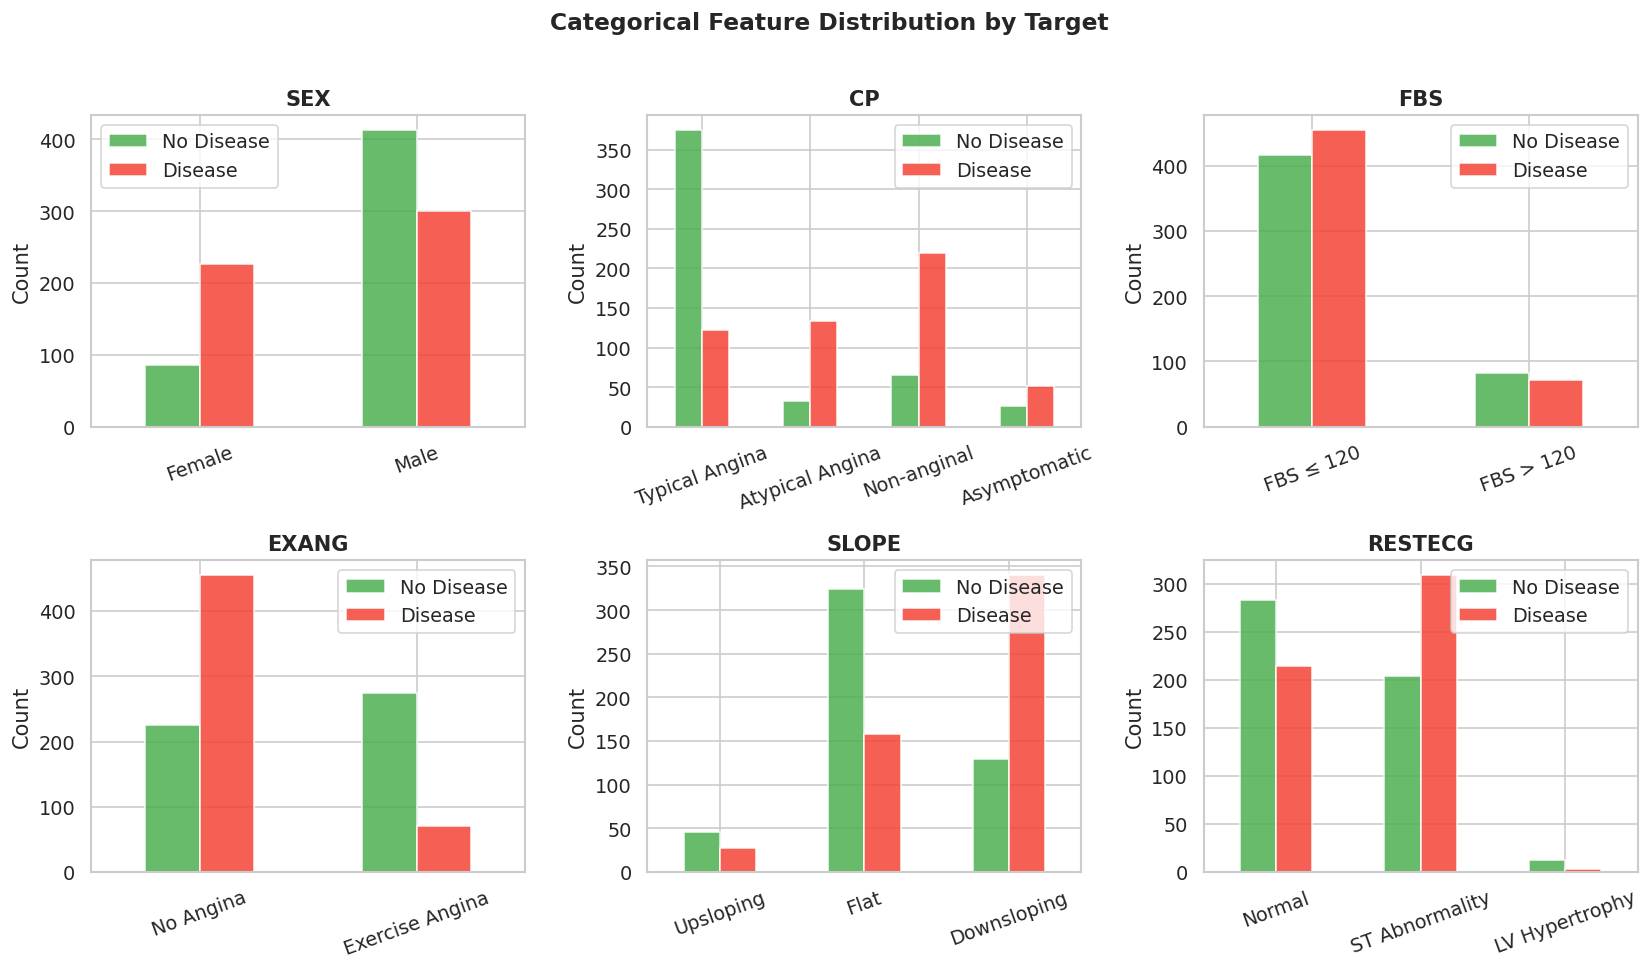

💡 Insights:
  • Males have higher disease frequency
  • Asymptomatic chest pain (cp=3) strongly associated with disease
  • Exercise-induced angina (exang=1) is a strong risk indicator


In [13]:
# ── EDA Plot 3: Categorical Features ────────────────────────────────
cat_features = ['sex', 'cp', 'fbs', 'exang', 'slope', 'restecg']
cat_labels = {
    'sex'    : {0: 'Female', 1: 'Male'},
    'cp'     : {0: 'Typical Angina', 1: 'Atypical Angina', 2: 'Non-anginal', 3: 'Asymptomatic'},
    'fbs'    : {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'exang'  : {0: 'No Angina', 1: 'Exercise Angina'},
    'slope'  : {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'restecg': {0: 'Normal', 1: 'ST Abnormality', 2: 'LV Hypertrophy'}
}

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df[feat], df['target'])
    ct.index = [cat_labels[feat].get(v, str(v)) for v in ct.index]
    ct.columns = ['No Disease', 'Disease']
    ct.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'],
            edgecolor='white', alpha=0.85)
    axes[i].set_title(feat.upper())
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Categorical Feature Distribution by Target', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('💡 Insights:')
print('  • Males have higher disease frequency')
print('  • Asymptomatic chest pain (cp=3) strongly associated with disease')
print('  • Exercise-induced angina (exang=1) is a strong risk indicator')

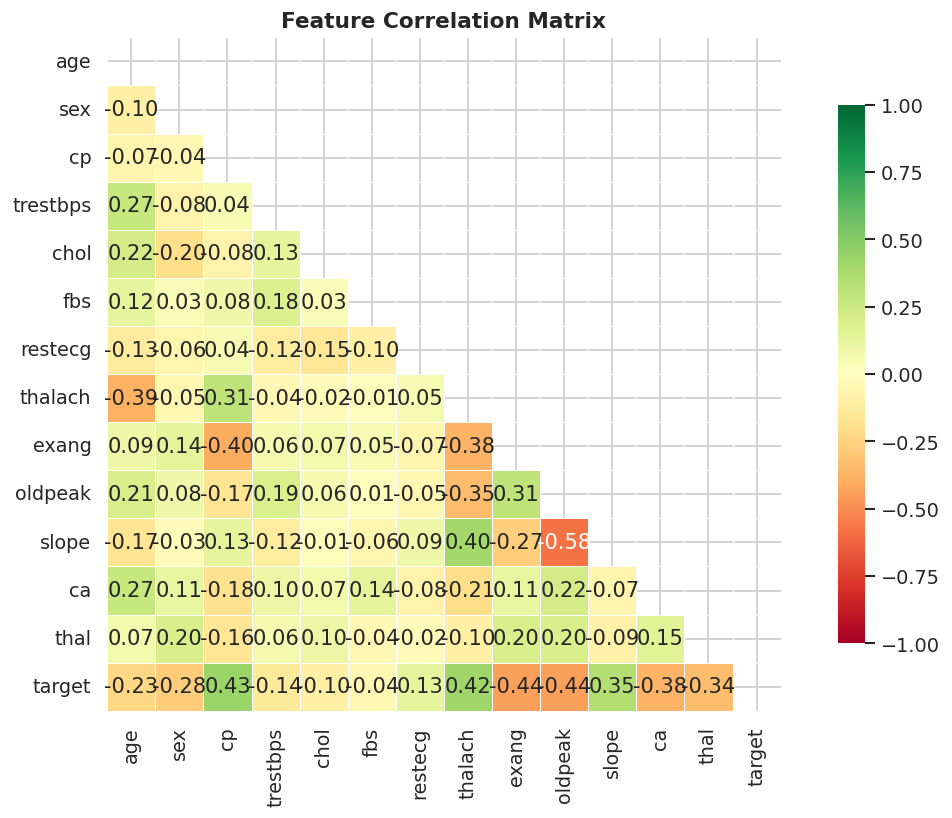


📊 Top correlations with target:
oldpeak    0.438
exang      0.438
cp         0.435
thalach    0.423
ca         0.382
slope      0.346
thal       0.338


In [14]:
# ── EDA Plot 4: Correlation Heatmap ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
corr = df.corr().round(2)
mask = np.triu(np.ones_like(corr, dtype=bool))   # upper triangle mask
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.4,
    cbar_kws={'shrink': 0.8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print('\n📊 Top correlations with target:')
print(target_corr.head(7).round(3).to_string())

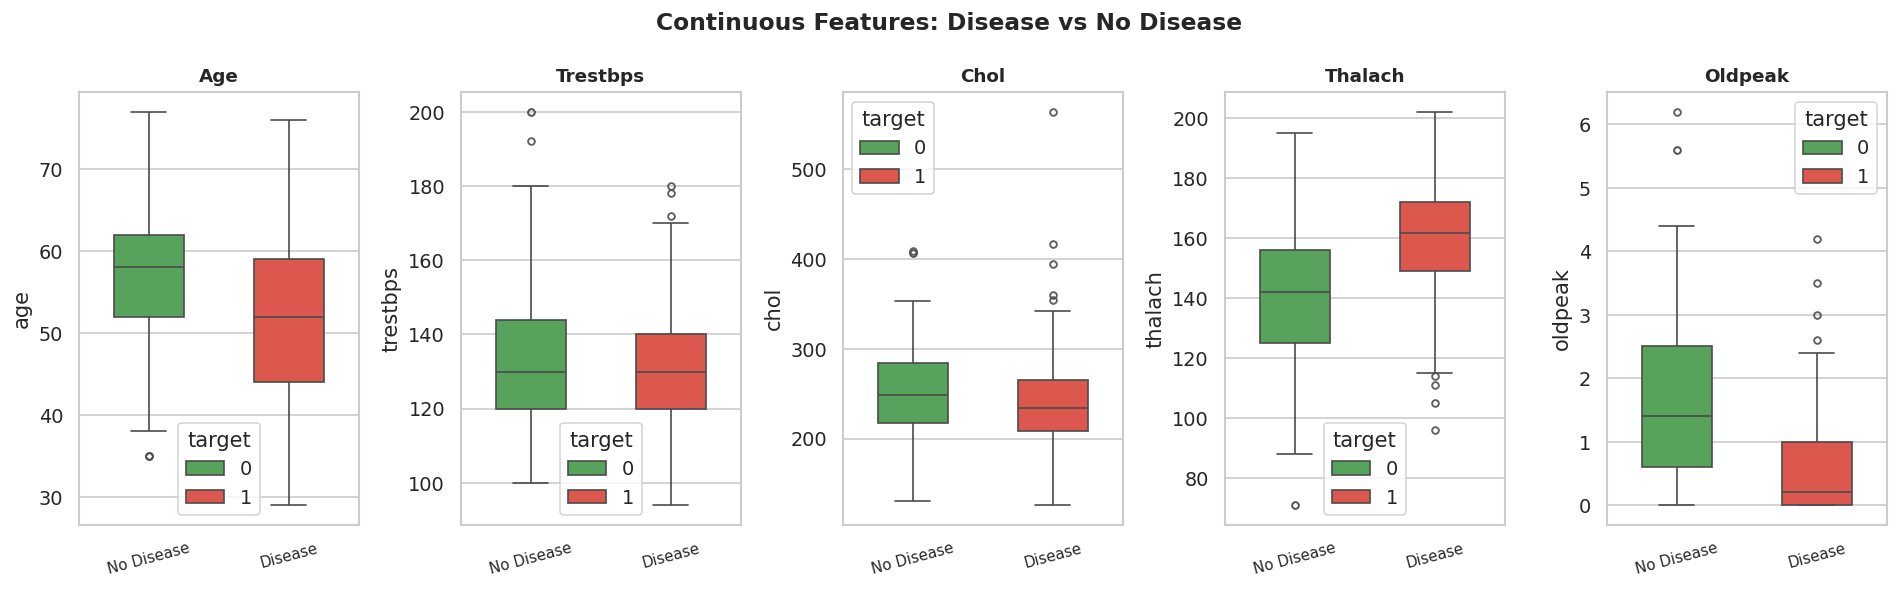

In [20]:
# ── EDA Plot 5: Box Plots — Continuous Features by Disease Status ────
fig, axes = plt.subplots(1, 5, figsize=(16, 5))

for i, feat in enumerate(cont_features):
    sns.boxplot(
        data=df, x='target', y=feat,
        hue='target',
        palette={0: '#4CAF50', 1: '#F44336'},
        # palette={'0': '#4CAF50', '1': '#F44336'},
        width=0.5,
        flierprops=dict(marker='o', markersize=4, alpha=0.5),
        ax=axes[i]
    )
    axes[i].set_xticklabels(['No Disease', 'Disease'], rotation=15, fontsize=9)
    axes[i].set_title(feat.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Continuous Features: Disease vs No Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 5: Data Preprocessing

In [21]:
# Separate features (X) and target (y)
X = df.drop('target', axis=1)
y = df['target']

print(f'Features shape : {X.shape}')
print(f'Target shape   : {y.shape}')
print(f'\nFeatures: {X.columns.tolist()}')

Features shape : (1025, 13)
Target shape   : (1025,)

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [22]:
# Train/Test split — stratified to maintain class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y        # ensures same class ratio in both splits
)

print(f'Train set : {X_train.shape[0]} samples  |  Disease rate: {y_train.mean():.2%}')
print(f'Test set  : {X_test.shape[0]} samples   |  Disease rate: {y_test.mean():.2%}')
print(f'\n✅ Stratified split maintains class balance.')

Train set : 820 samples  |  Disease rate: 51.34%
Test set  : 205 samples   |  Disease rate: 51.22%

✅ Stratified split maintains class balance.


In [23]:
# Feature Scaling — required for Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_sc  = scaler.transform(X_test)        # only transform test (no leakage)

print('✅ StandardScaler applied.')
print(f'   Mean (first 3 features after scaling): {X_train_sc[:, :3].mean(axis=0).round(4)}')

✅ StandardScaler applied.
   Mean (first 3 features after scaling): [-0.  0.  0.]


---
## Step 6: Train Models

### 6.1 — Logistic Regression

In [24]:
# Logistic Regression — linear decision boundary
lr = LogisticRegression(
    C=1.0,            # regularization strength (inverse)
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_sc, y_train)
lr_preds      = lr.predict(X_test_sc)
lr_probs      = lr.predict_proba(X_test_sc)[:, 1]   # probabilities for ROC
lr_acc        = accuracy_score(y_test, lr_preds)
lr_auc        = roc_auc_score(y_test, lr_probs)

print('━' * 45)
print('   Logistic Regression Results')
print('━' * 45)
print(f'  Accuracy : {lr_acc:.4f}  ({lr_acc*100:.2f}%)')
print(f'  ROC-AUC  : {lr_auc:.4f}')
print('━' * 45)
print('\n📋 Classification Report:')
print(classification_report(y_test, lr_preds,
                             target_names=['No Disease', 'Disease']))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Logistic Regression Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy : 0.8098  (80.98%)
  ROC-AUC  : 0.9298
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 Classification Report:
              precision    recall  f1-score   support

  No Disease       0.89      0.70      0.78       100
     Disease       0.76      0.91      0.83       105

    accuracy                           0.81       205
   macro avg       0.82      0.81      0.81       205
weighted avg       0.82      0.81      0.81       205



### 6.2 — Decision Tree Classifier

In [25]:
# Decision Tree — no scaling needed
dt = DecisionTreeClassifier(
    max_depth=5,           # limit depth to avoid overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)
dt_probs = dt.predict_proba(X_test)[:, 1]
dt_acc   = accuracy_score(y_test, dt_preds)
dt_auc   = roc_auc_score(y_test, dt_probs)

print('━' * 45)
print('   Decision Tree Results')
print('━' * 45)
print(f'  Accuracy : {dt_acc:.4f}  ({dt_acc*100:.2f}%)')
print(f'  ROC-AUC  : {dt_auc:.4f}')
print('━' * 45)
print('\n📋 Classification Report:')
print(classification_report(y_test, dt_preds,
                             target_names=['No Disease', 'Disease']))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Decision Tree Results
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Accuracy : 0.8829  (88.29%)
  ROC-AUC  : 0.9495
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 Classification Report:
              precision    recall  f1-score   support

  No Disease       0.87      0.90      0.88       100
     Disease       0.90      0.87      0.88       105

    accuracy                           0.88       205
   macro avg       0.88      0.88      0.88       205
weighted avg       0.88      0.88      0.88       205



### 6.3 — Cross-Validation (5-Fold Stratified)

In [26]:
# 5-fold cross-validation gives more reliable accuracy estimates
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                        X_train_sc, y_train, cv=skf, scoring='roc_auc')
dt_cv = cross_val_score(DecisionTreeClassifier(max_depth=5, random_state=42),
                        X_train, y_train, cv=skf, scoring='roc_auc')

print('━' * 50)
print('   5-Fold Cross-Validation (ROC-AUC)')
print('━' * 50)
print(f'  Logistic Regression : {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')
print(f'  Decision Tree       : {dt_cv.mean():.4f} ± {dt_cv.std():.4f}')
print('━' * 50)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   5-Fold Cross-Validation (ROC-AUC)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Logistic Regression : 0.9156 ± 0.0145
  Decision Tree       : 0.9462 ± 0.0134
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


---
## Step 7: Evaluation Plots

### 7.1 — Confusion Matrices

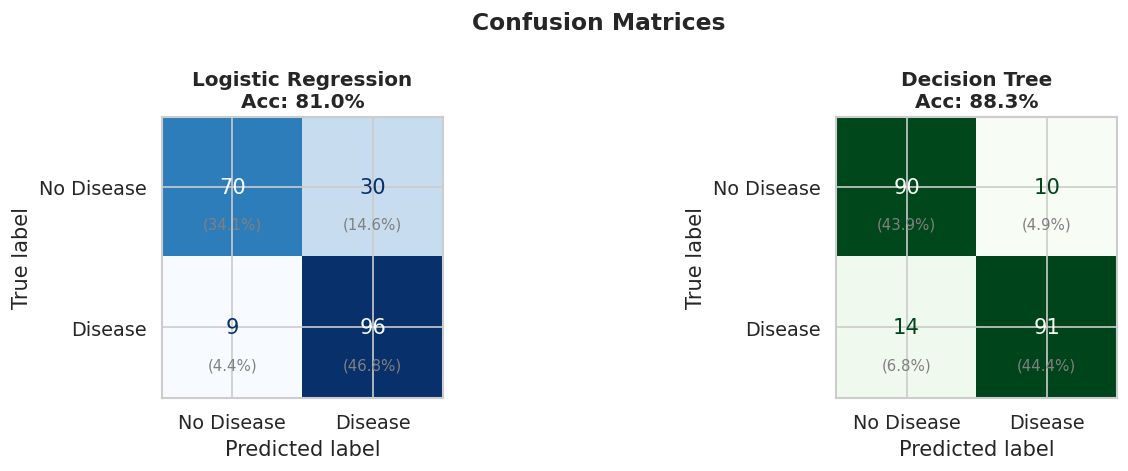


📌 Matrix Interpretation:
  TN (top-left)  = Correctly predicted No Disease
  FP (top-right) = No Disease predicted as Disease (False Alarm)
  FN (bot-left)  = Disease predicted as No Disease ⚠️ (Dangerous Miss)
  TP (bot-right) = Correctly predicted Disease


In [27]:
# Confusion matrix for both models side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, preds, title, cmap in zip(
    axes,
    [lr_preds, dt_preds],
    ['Logistic Regression', 'Decision Tree'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No Disease', 'Disease'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{title}\nAcc: {accuracy_score(y_test, preds)*100:.1f}%', fontsize=12)

    # Add percentage annotations below counts
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / total * 100
            ax.text(j, i + 0.3, f'({pct:.1f}%)', ha='center',
                    fontsize=9, color='gray')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Explain the matrix
print('\n📌 Matrix Interpretation:')
print('  TN (top-left)  = Correctly predicted No Disease')
print('  FP (top-right) = No Disease predicted as Disease (False Alarm)')
print('  FN (bot-left)  = Disease predicted as No Disease ⚠️ (Dangerous Miss)')
print('  TP (bot-right) = Correctly predicted Disease')

### 7.2 — ROC Curves

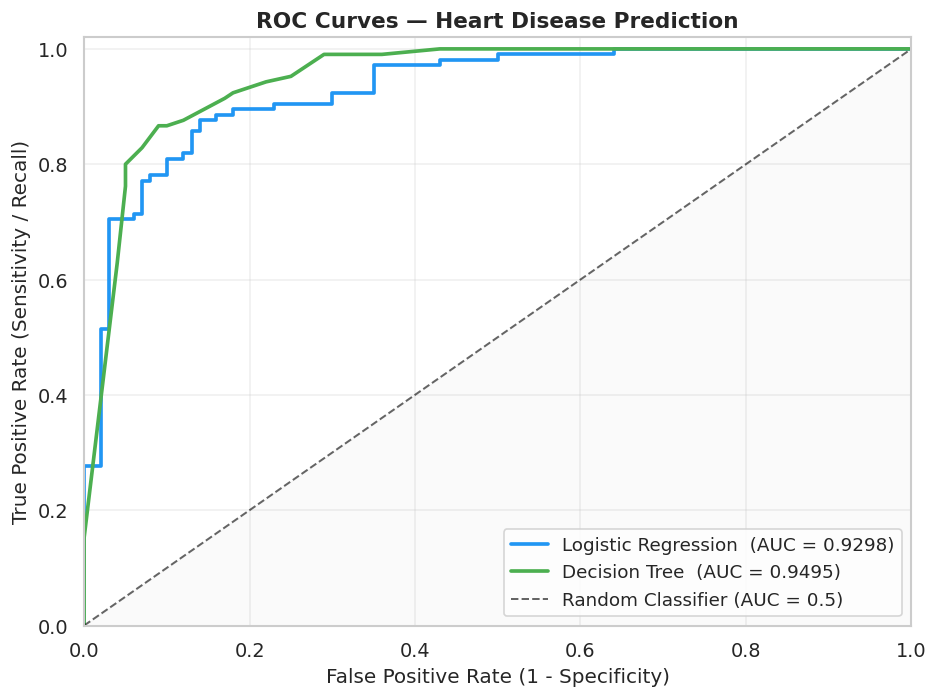


💡 AUC Interpretation Guide:
  0.90–1.00 = Excellent  |  0.80–0.90 = Good
  0.70–0.80 = Fair       |  0.60–0.70 = Poor
  0.50      = No better than random


In [28]:
# ROC Curve: Trade-off between True Positive Rate and False Positive Rate
fig, ax = plt.subplots(figsize=(8, 6))

for probs, label, color, auc in zip(
    [lr_probs, dt_probs],
    ['Logistic Regression', 'Decision Tree'],
    ['#2196F3', '#4CAF50'],
    [lr_auc, dt_auc]
):
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, color=color, linewidth=2.2,
            label=f'{label}  (AUC = {auc:.4f})')

# Diagonal baseline (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6, label='Random Classifier (AUC = 0.5)')

ax.fill_between([0, 1], [0, 1], alpha=0.04, color='gray')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
ax.set_title('ROC Curves — Heart Disease Prediction', fontsize=13)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n💡 AUC Interpretation Guide:')
print('  0.90–1.00 = Excellent  |  0.80–0.90 = Good')
print('  0.70–0.80 = Fair       |  0.60–0.70 = Poor')
print('  0.50      = No better than random')

### 7.3 — Precision-Recall Curve

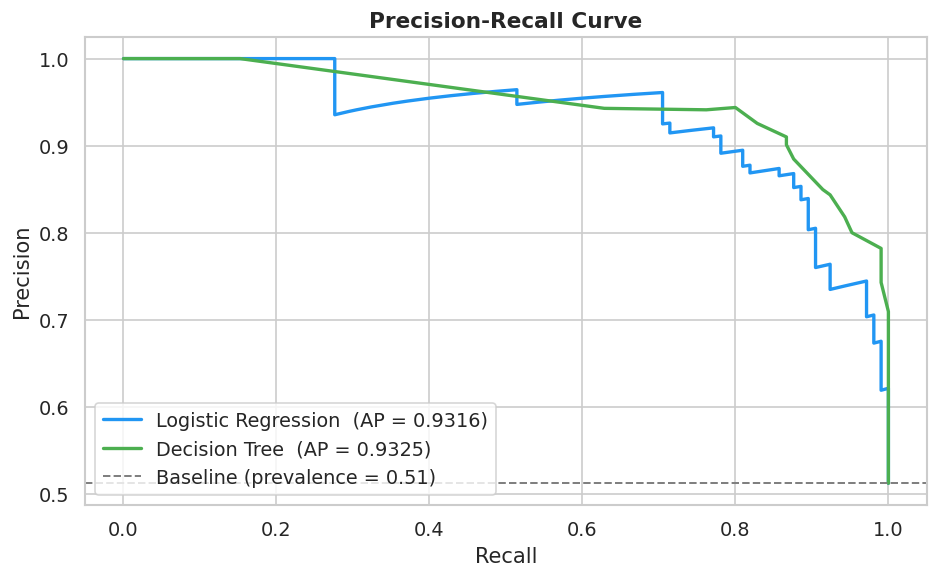

💡 Important in medical context: High Recall = fewer missed disease cases.


In [29]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 5))

for probs, label, color in zip(
    [lr_probs, dt_probs],
    ['Logistic Regression', 'Decision Tree'],
    ['#2196F3', '#4CAF50']
):
    prec, rec, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    ax.plot(rec, prec, color=color, linewidth=2,
            label=f'{label}  (AP = {ap:.4f})')

ax.axhline(y_test.mean(), color='gray', linestyle='--',
           linewidth=1.2, label=f'Baseline (prevalence = {y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=13)
ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

print('💡 Important in medical context: High Recall = fewer missed disease cases.')

---
## Step 8: Feature Importance Analysis

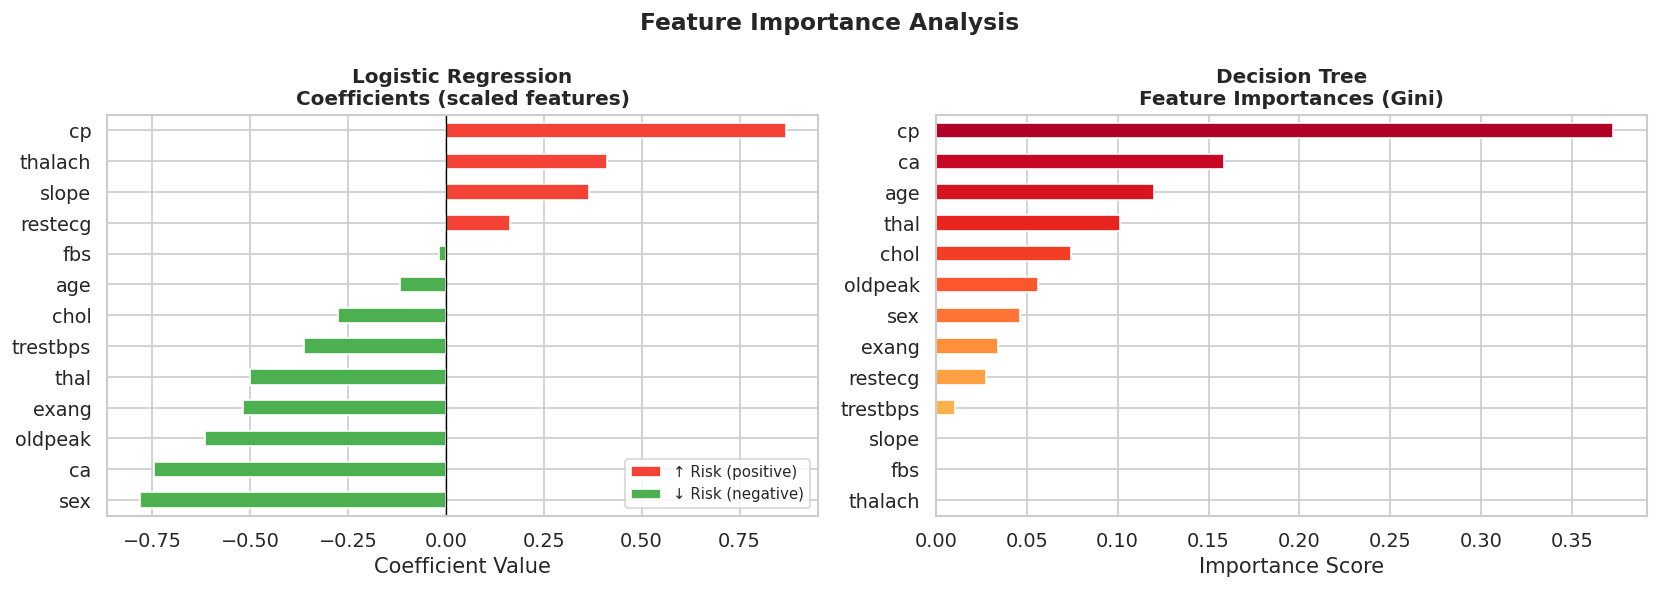


🏅 Top 5 Features by Decision Tree Importance:
  1. cp           → 0.3723
  2. ca           → 0.1582
  3. age          → 0.1199
  4. thal         → 0.1010
  5. chol         → 0.0742


In [30]:
# ── 8.1 Logistic Regression Coefficients ────────────────────────────
feature_names = X.columns.tolist()
lr_coefs = pd.Series(lr.coef_[0], index=feature_names).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color bars by direction
colors_lr = ['#F44336' if v > 0 else '#4CAF50' for v in lr_coefs]
lr_coefs.plot(kind='barh', ax=axes[0], color=colors_lr, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Logistic Regression\nCoefficients (scaled features)', fontsize=12)
axes[0].set_xlabel('Coefficient Value')
# Add legend
from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(fc='#F44336', label='↑ Risk (positive)'),
    Patch(fc='#4CAF50', label='↓ Risk (negative)')
], fontsize=9, loc='lower right')

# ── 8.2 Decision Tree Feature Importances ───────────────────────────
dt_imp = pd.Series(dt.feature_importances_, index=feature_names).sort_values()
dt_imp.plot(kind='barh', ax=axes[1],
            color=plt.cm.YlOrRd(np.linspace(0.2, 0.9, len(dt_imp))),
            edgecolor='white')
axes[1].set_title('Decision Tree\nFeature Importances (Gini)', fontsize=12)
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n🏅 Top 5 Features by Decision Tree Importance:')
for i, (feat, val) in enumerate(dt_imp.sort_values(ascending=False).head(5).items(), 1):
    print(f'  {i}. {feat:12s} → {val:.4f}')

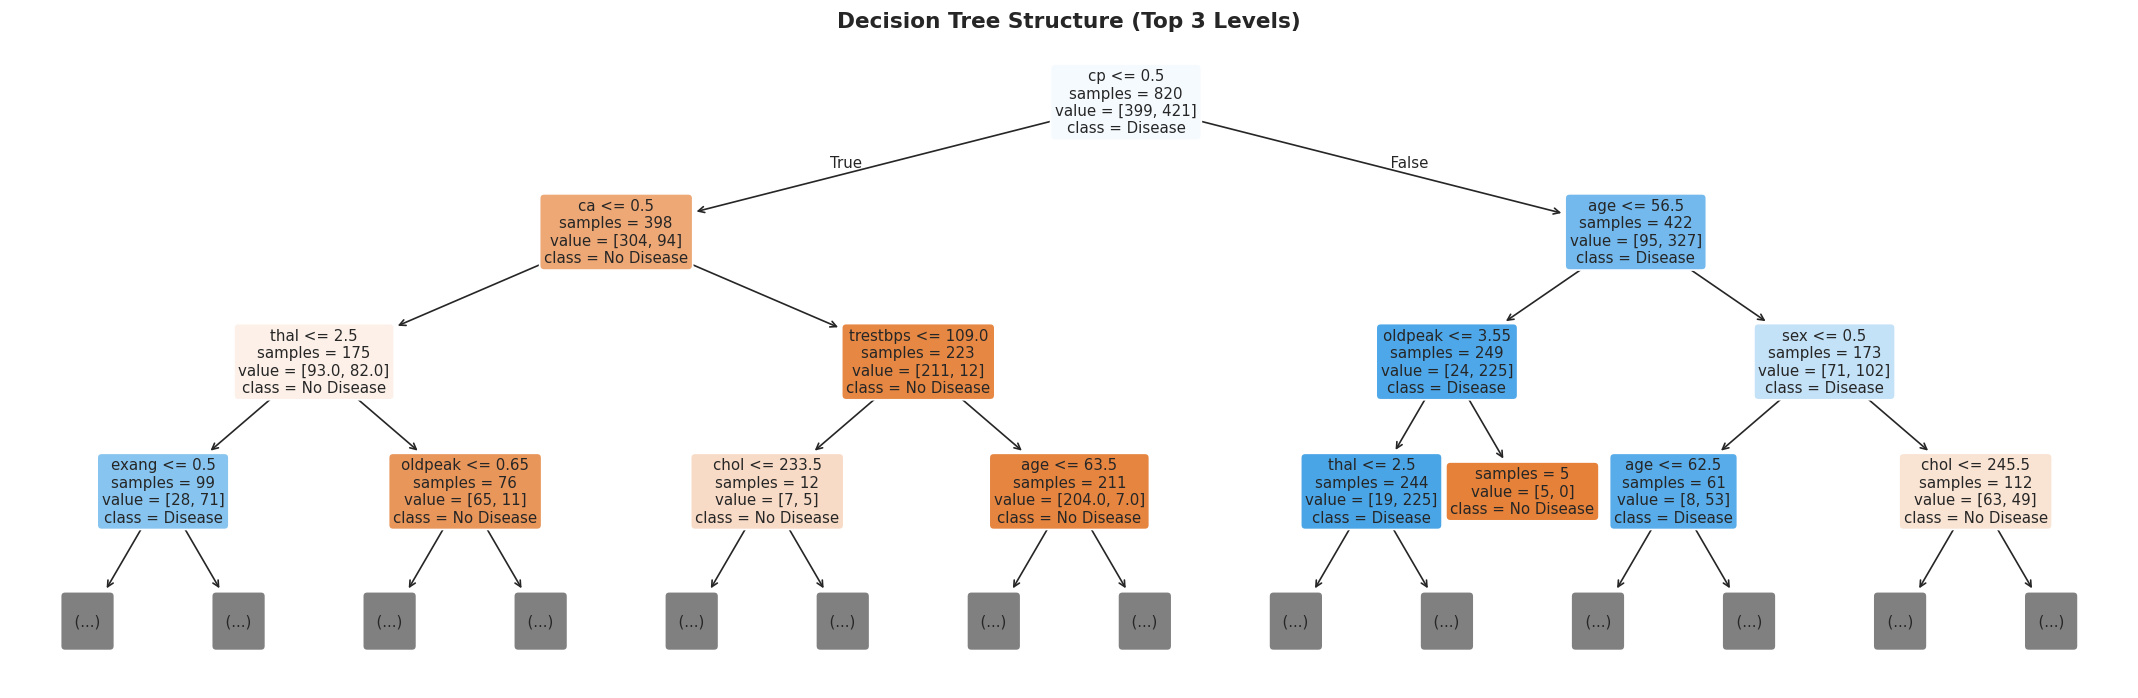

💡 Leaf nodes show predicted class. Orange = Disease, Blue = No Disease.


In [31]:
# ── 8.3 Decision Tree Visualization ─────────────────────────────────
# Plot first 3 levels of the tree for readability
fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt, ax=ax,
    feature_names=feature_names,
    class_names=['No Disease', 'Disease'],
    filled=True,
    rounded=True,
    max_depth=3,           # show only top 3 levels
    fontsize=9,
    impurity=False
)
ax.set_title('Decision Tree Structure (Top 3 Levels)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('💡 Leaf nodes show predicted class. Orange = Disease, Blue = No Disease.')

---
## Step 9: Model Comparison Dashboard

📊 Complete Model Comparison:
              Model  Accuracy  ROC-AUC  Precision  Recall  F1 Score  CV AUC
Logistic Regression     80.98   0.9298      76.19   91.43     83.12  0.9156
      Decision Tree     88.29   0.9495      90.10   86.67     88.35  0.9462


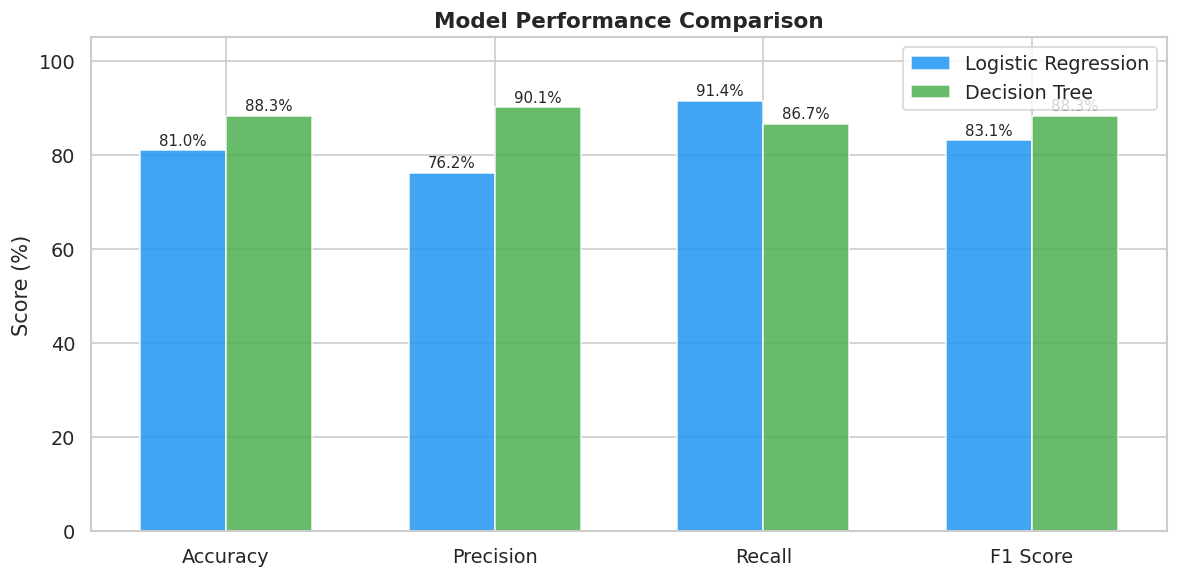


🏆 Best Model (by ROC-AUC): Decision Tree


In [32]:
from sklearn.metrics import recall_score, precision_score, f1_score

# Compile all metrics
metrics_df = pd.DataFrame({
    'Model'    : ['Logistic Regression', 'Decision Tree'],
    'Accuracy' : [round(lr_acc*100, 2), round(dt_acc*100, 2)],
    'ROC-AUC'  : [round(lr_auc, 4), round(dt_auc, 4)],
    'Precision': [round(precision_score(y_test, lr_preds)*100, 2),
                  round(precision_score(y_test, dt_preds)*100, 2)],
    'Recall'   : [round(recall_score(y_test, lr_preds)*100, 2),
                  round(recall_score(y_test, dt_preds)*100, 2)],
    'F1 Score' : [round(f1_score(y_test, lr_preds)*100, 2),
                  round(f1_score(y_test, dt_preds)*100, 2)],
    'CV AUC'   : [round(lr_cv.mean(), 4), round(dt_cv.mean(), 4)]
})

print('📊 Complete Model Comparison:')
print(metrics_df.to_string(index=False))

# Radar/bar comparison chart
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metric_cols))
w = 0.32

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - w/2, metrics_df.iloc[0][metric_cols], w,
               label='Logistic Regression', color='#2196F3', edgecolor='white', alpha=0.85)
bars2 = ax.bar(x + w/2, metrics_df.iloc[1][metric_cols], w,
               label='Decision Tree', color='#4CAF50', edgecolor='white', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(metric_cols)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('Model Performance Comparison', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

best_model = metrics_df.loc[metrics_df['ROC-AUC'].idxmax(), 'Model']
print(f'\n🏆 Best Model (by ROC-AUC): {best_model}')

---
## Step 10: Predict for a New Patient

In [33]:
# Predict heart disease risk for a hypothetical new patient
# Feature order: age, sex, cp, trestbps, chol, fbs, restecg,
#                thalach, exang, oldpeak, slope, ca, thal

new_patient = pd.DataFrame([{
    'age': 55, 'sex': 1, 'cp': 3, 'trestbps': 140,
    'chol': 260, 'fbs': 1, 'restecg': 0, 'thalach': 130,
    'exang': 1, 'oldpeak': 2.5, 'slope': 1, 'ca': 1, 'thal': 3
}])

# Scale for logistic regression
new_scaled = scaler.transform(new_patient)

# Predictions
lr_pred_new = lr.predict(new_scaled)[0]
lr_prob_new = lr.predict_proba(new_scaled)[0][1]
dt_pred_new = dt.predict(new_patient)[0]
dt_prob_new = dt.predict_proba(new_patient)[0][1]

print('=' * 50)
print('   NEW PATIENT RISK ASSESSMENT')
print('=' * 50)
print(f'  Patient: Male, 55 yrs | High BP | High Chol')
print(f'           Asymptomatic CP | Exercise Angina')
print()
print(f'  Logistic Regression:')
print(f'    Prediction : {"⚠️  DISEASE" if lr_pred_new else "✅ NO DISEASE"}')
print(f'    Confidence : {lr_prob_new*100:.1f}% risk')
print()
print(f'  Decision Tree:')
print(f'    Prediction : {"⚠️  DISEASE" if dt_pred_new else "✅ NO DISEASE"}')
print(f'    Confidence : {dt_prob_new*100:.1f}% risk')
print('=' * 50)
print('\n⚕️  Note: This is for educational purposes only.')
print('    Always consult a medical professional for diagnosis.')

   NEW PATIENT RISK ASSESSMENT
  Patient: Male, 55 yrs | High BP | High Chol
           Asymptomatic CP | Exercise Angina

  Logistic Regression:
    Prediction : ✅ NO DISEASE
    Confidence : 11.3% risk

  Decision Tree:
    Prediction : ⚠️  DISEASE
    Confidence : 88.9% risk

⚕️  Note: This is for educational purposes only.
    Always consult a medical professional for diagnosis.


---
## Step 11: Final Insights & Conclusion


In [34]:
# Final Summary Print
print('=' * 55)
print('     HEART DISEASE PREDICTION — FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset      : UCI Heart Disease (Cleveland)')
print(f'  Samples      : {len(df)} patients')
print(f'  Features     : {X.shape[1]}')
print(f'  Train/Test   : {len(X_train)}/{len(X_test)} (80/20 stratified)')
print()
print(f'  Logistic Regression → Acc: {lr_acc*100:.2f}%  |  AUC: {lr_auc:.4f}')
print(f'  Decision Tree       → Acc: {dt_acc*100:.2f}%  |  AUC: {dt_auc:.4f}')
print()
print(f'  🏆 Best Model : {best_model}')
print(f'  🔑 Top Features: cp, thalach, oldpeak, ca, exang')
print('=' * 55)

     HEART DISEASE PREDICTION — FINAL SUMMARY
  Dataset      : UCI Heart Disease (Cleveland)
  Samples      : 1025 patients
  Features     : 13
  Train/Test   : 820/205 (80/20 stratified)

  Logistic Regression → Acc: 80.98%  |  AUC: 0.9298
  Decision Tree       → Acc: 88.29%  |  AUC: 0.9495

  🏆 Best Model : Decision Tree
  🔑 Top Features: cp, thalach, oldpeak, ca, exang
